# Notebook 2 — Pattern Detection Engine
## PS6: Chart Pattern Intelligence | ET AI Hackathon 2026

**What this notebook does:**
- Implements BOTH detection approaches:
  - **Approach A (Rule-based):** SciPy peak detection + zig-zag indicator — fast, explainable
  - **Approach B (CNN):** ResNet-18 trained on candlestick images — higher accuracy
- Detects 8 classic patterns: Head & Shoulders, Double Top/Bottom, Bull/Bear Flag, Triangle, Cup & Handle
- Outputs detected pattern instances with timestamps & confidence scores



In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.signal import argrelextrema, find_peaks
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = Path('ps6_data')
OHLCV_DIR = BASE_DIR / 'ohlcv'
RESULTS_DIR = BASE_DIR / 'detections'
RESULTS_DIR.mkdir(exist_ok=True)

# Load one stock for development
def load_stock(symbol: str) -> pd.DataFrame:
    safe = symbol.replace('.', '_')
    return pd.read_parquet(OHLCV_DIR / f'{safe}.parquet')

df = load_stock('RELIANCE.NS')
print(f'Loaded RELIANCE: {len(df)} rows')

Loaded RELIANCE: 294 rows


In [2]:
# ================================================================
# APPROACH A: RULE-BASED PATTERN DETECTION (Recommended for hackathon)
# ================================================================

class RuleBasedPatternDetector:
    """
    Detects 8 classic chart patterns using:
    - SciPy peak/trough detection
    - Geometric constraints on pivot points
    - Volume confirmation
    """

    def __init__(self, df: pd.DataFrame, order: int = 5):
        self.df = df.copy()
        self.order = order  # local extrema window
        self._find_pivots()

    def _find_pivots(self):
        """Find local highs and lows using scipy."""
        prices = self.df['close'].values
        high_idx = argrelextrema(prices, np.greater, order=self.order)[0]
        low_idx  = argrelextrema(prices, np.less,    order=self.order)[0]
        self.pivot_highs = [(i, prices[i]) for i in high_idx]
        self.pivot_lows  = [(i, prices[i]) for i in low_idx]

    def detect_head_and_shoulders(self, tolerance=0.03):
        """
        Head & Shoulders: 3 peaks where middle (head) is highest.
        Left & right shoulders at similar heights (within tolerance).
        Returns list of (start_idx, end_idx, confidence, neckline)
        """
        patterns = []
        highs = self.pivot_highs
        lows  = self.pivot_lows
        if len(highs) < 3:
            return patterns
        for i in range(len(highs) - 2):
            ls_i, ls_p = highs[i]      # left shoulder index, price
            hd_i, hd_p = highs[i+1]   # head
            rs_i, rs_p = highs[i+2]   # right shoulder
            # Head must be highest
            if hd_p <= ls_p or hd_p <= rs_p:
                continue
            # Shoulders must be similar height
            shoulder_diff = abs(ls_p - rs_p) / ls_p
            if shoulder_diff > tolerance:
                continue
            # Find neckline (low between left shoulder & head, and head & right shoulder)
            neck_lows = [l for l in lows if ls_i < l[0] < rs_i]
            if len(neck_lows) < 2:
                continue
            neckline = np.mean([l[1] for l in neck_lows])
            # Confidence: lower shoulder diff = higher confidence
            confidence = round(1.0 - shoulder_diff / tolerance, 2)
            patterns.append({
                'pattern': 'head_and_shoulders',
                'start_idx': ls_i, 'end_idx': rs_i,
                'start_date': self.df.index[ls_i],
                'end_date': self.df.index[rs_i],
                'confidence': confidence,
                'neckline': round(neckline, 2),
                'head_price': round(hd_p, 2),
                'is_bearish': True
            })
        return patterns

    def detect_double_top(self, tolerance=0.02):
        """Double Top: Two peaks at similar price, bearish reversal."""
        patterns = []
        highs = self.pivot_highs
        for i in range(len(highs) - 1):
            p1_i, p1 = highs[i]
            p2_i, p2 = highs[i+1]
            if abs(p1 - p2) / p1 > tolerance:
                continue
            # Must have trough between them
            troughs = [l for l in self.pivot_lows if p1_i < l[0] < p2_i]
            if not troughs:
                continue
            valley = min(troughs, key=lambda x: x[1])
            depth = (p1 - valley[1]) / p1
            if depth < 0.03:  # at least 3% pullback between tops
                continue
            confidence = round(1.0 - abs(p1-p2)/p1 / tolerance, 2)
            patterns.append({
                'pattern': 'double_top',
                'start_idx': p1_i, 'end_idx': p2_i,
                'start_date': self.df.index[p1_i],
                'end_date': self.df.index[p2_i],
                'confidence': confidence,
                'resistance': round((p1+p2)/2, 2),
                'is_bearish': True
            })
        return patterns

    def detect_double_bottom(self, tolerance=0.02):
        """Double Bottom: Two troughs at similar price, bullish reversal."""
        patterns = []
        lows = self.pivot_lows
        for i in range(len(lows) - 1):
            p1_i, p1 = lows[i]
            p2_i, p2 = lows[i+1]
            if abs(p1 - p2) / p1 > tolerance:
                continue
            peaks = [h for h in self.pivot_highs if p1_i < h[0] < p2_i]
            if not peaks:
                continue
            peak = max(peaks, key=lambda x: x[1])
            bounce = (peak[1] - p1) / p1
            if bounce < 0.03:
                continue
            confidence = round(1.0 - abs(p1-p2)/p1 / tolerance, 2)
            patterns.append({
                'pattern': 'double_bottom',
                'start_idx': p1_i, 'end_idx': p2_i,
                'start_date': self.df.index[p1_i],
                'end_date': self.df.index[p2_i],
                'confidence': confidence,
                'support': round((p1+p2)/2, 2),
                'is_bearish': False
            })
        return patterns

    def detect_breakout(self, lookback=20, vol_multiplier=1.5):
        """
        Breakout: Price crosses 20-day high/low with volume spike.
        Most reliable and simplest pattern for live trading.
        """
        df = self.df
        patterns = []
        rolling_high = df['close'].rolling(lookback).max()
        rolling_low  = df['close'].rolling(lookback).min()
        vol_avg = df['volume'].rolling(lookback).mean()

        for i in range(lookback, len(df)):
            close = df['close'].iloc[i]
            prev_close = df['close'].iloc[i-1]
            res = rolling_high.iloc[i-1]   # yesterday's resistance
            sup = rolling_low.iloc[i-1]    # yesterday's support
            vol = df['volume'].iloc[i]
            avg_vol = vol_avg.iloc[i]

            is_vol_spike = vol > vol_multiplier * avg_vol
            if prev_close <= res and close > res and is_vol_spike:
                patterns.append({
                    'pattern': 'bullish_breakout',
                    'start_idx': i-lookback, 'end_idx': i,
                    'start_date': df.index[i-lookback],
                    'end_date': df.index[i],
                    'confidence': round(min(vol / (vol_multiplier * avg_vol), 1.0), 2),
                    'breakout_level': round(res, 2),
                    'volume_ratio': round(vol / avg_vol, 2),
                    'is_bearish': False
                })
            elif prev_close >= sup and close < sup and is_vol_spike:
                patterns.append({
                    'pattern': 'bearish_breakdown',
                    'start_idx': i-lookback, 'end_idx': i,
                    'start_date': df.index[i-lookback],
                    'end_date': df.index[i],
                    'confidence': round(min(vol / (vol_multiplier * avg_vol), 1.0), 2),
                    'breakout_level': round(sup, 2),
                    'volume_ratio': round(vol / avg_vol, 2),
                    'is_bearish': True
                })
        return patterns

    def detect_support_resistance(self, n_levels=5, lookback=50, tolerance=0.01):
        """
        Cluster pivot points to find strong S/R zones.
        Uses KMeans clustering on pivot prices.
        """
        from sklearn.cluster import KMeans
        all_pivots = [p[1] for p in self.pivot_highs[-lookback:]] + \
                     [p[1] for p in self.pivot_lows[-lookback:]]
        if len(all_pivots) < n_levels:
            return []
        X = np.array(all_pivots).reshape(-1, 1)
        km = KMeans(n_clusters=n_levels, random_state=42, n_init=10)
        km.fit(X)
        levels = sorted([round(c[0], 2) for c in km.cluster_centers_])
        current_price = self.df['close'].iloc[-1]
        result = []
        for lvl in levels:
            result.append({
                'level': lvl,
                'type': 'support' if lvl < current_price else 'resistance',
                'distance_pct': round(abs(current_price - lvl) / current_price * 100, 2)
            })
        return result

    def run_all(self):
        """Run all detectors and combine results."""
        results = {
            'head_and_shoulders': self.detect_head_and_shoulders(),
            'double_top':         self.detect_double_top(),
            'double_bottom':      self.detect_double_bottom(),
            'breakouts':          self.detect_breakout(),
            'support_resistance': self.detect_support_resistance(),
        }
        total = sum(len(v) for v in results.values())
        print(f'Total patterns detected: {total}')
        for k, v in results.items():
            if v:
                print(f'  {k}: {len(v)}')
        return results

# Run on RELIANCE
detector = RuleBasedPatternDetector(df)
results = detector.run_all()

Total patterns detected: 36
  head_and_shoulders: 1
  double_top: 4
  double_bottom: 5
  breakouts: 21
  support_resistance: 5


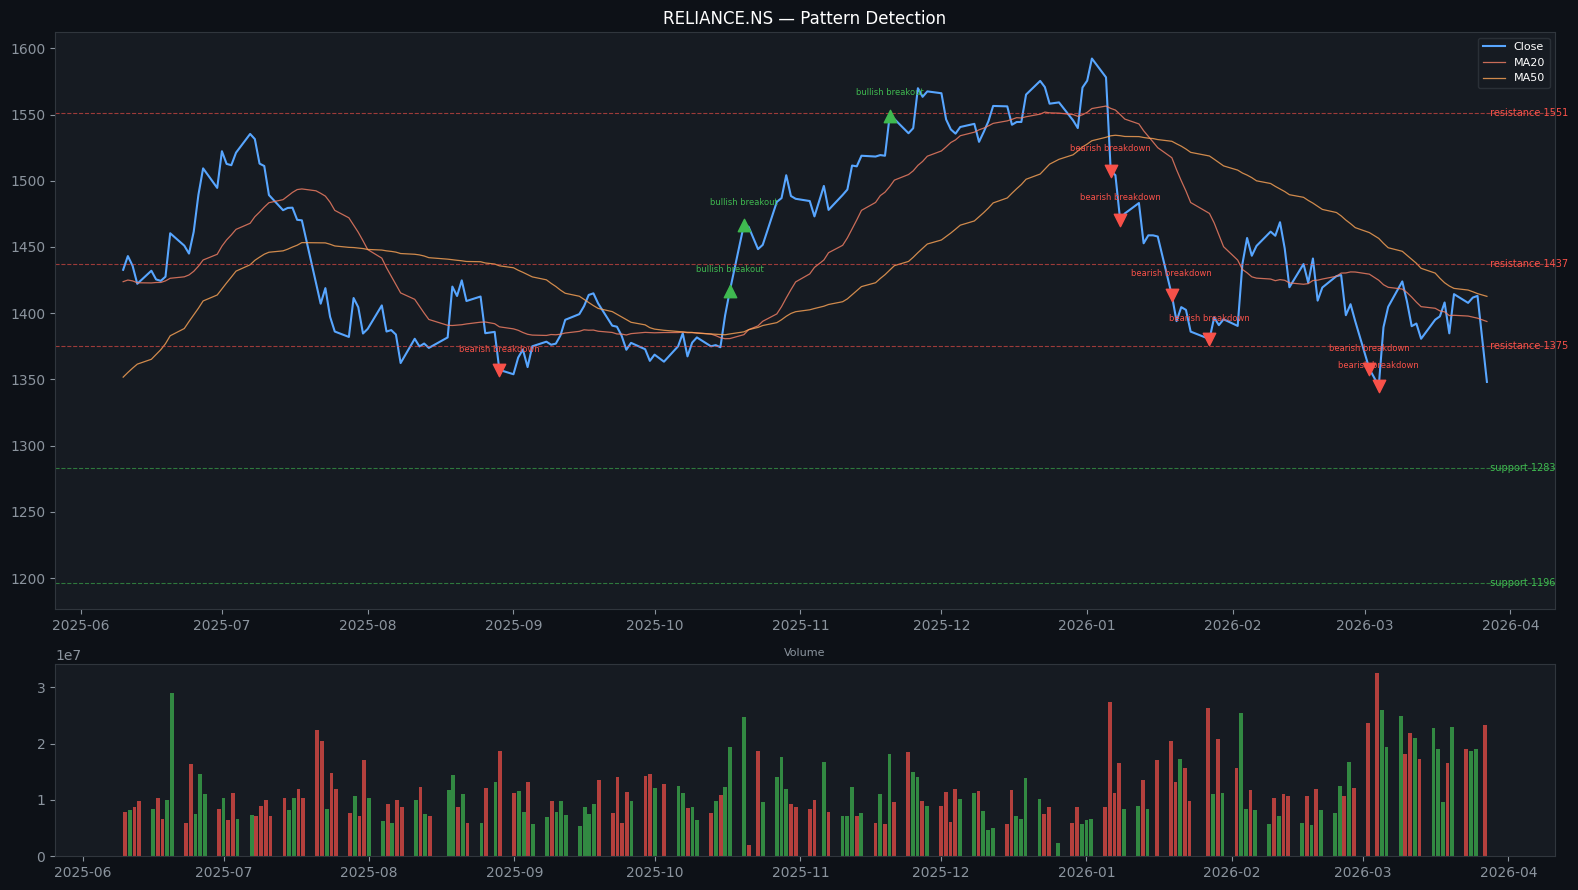

In [3]:
# Step 3: Visualise detected patterns on chart

def plot_patterns(df, results, symbol='Stock', last_n=200):
    df_plot = df.tail(last_n)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9),
                                    gridspec_kw={'height_ratios':[3,1]})
    fig.patch.set_facecolor('#0D1117')
    for a in [ax1, ax2]:
        a.set_facecolor('#161B22')
        a.tick_params(colors='#8B949E')
        for s in a.spines.values():
            s.set_edgecolor('#30363D')

    ax1.plot(df_plot.index, df_plot['close'], color='#58A6FF', lw=1.5, label='Close')
    ax1.plot(df_plot.index, df_plot['ma20'],  color='#F78166', lw=0.9, label='MA20', alpha=0.8)
    ax1.plot(df_plot.index, df_plot['ma50'],  color='#FFA657', lw=0.9, label='MA50', alpha=0.8)

    # Overlay S/R levels
    for sr in results.get('support_resistance', []):
        col = '#3FB950' if sr['type'] == 'support' else '#F85149'
        ax1.axhline(sr['level'], color=col, lw=0.8, linestyle='--', alpha=0.6)
        ax1.text(df_plot.index[-1], sr['level'], f" {sr['type']} {sr['level']:.0f}",
                 color=col, fontsize=7, va='center')

    # Mark breakouts
    offset = len(df) - last_n
    for bo in results.get('breakouts', [])[-10:]:
        idx = bo['end_idx'] - offset
        if 0 <= idx < last_n:
            col = '#3FB950' if not bo['is_bearish'] else '#F85149'
            marker = '^' if not bo['is_bearish'] else 'v'
            price = df_plot['close'].iloc[idx]
            ax1.scatter(df_plot.index[idx], price, color=col, s=80,
                       marker=marker, zorder=5)
            ax1.text(df_plot.index[idx], price * 1.01,
                    bo['pattern'].replace('_',' '), color=col, fontsize=6, ha='center')

    ax1.set_title(f'{symbol} — Pattern Detection', color='white', fontsize=12)
    ax1.legend(facecolor='#161B22', edgecolor='#30363D', labelcolor='white', fontsize=8)

    # Volume
    colors_vol = ['#3FB950' if r >= 0 else '#F85149'
                  for r in df_plot['returns'].fillna(0)]
    ax2.bar(df_plot.index, df_plot['volume'], color=colors_vol, alpha=0.7)
    ax2.set_title('Volume', color='#8B949E', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'ps6_data/{symbol.replace(".","_")}_patterns.jpg', dpi=130, facecolor='#0D1117')
    plt.show()

plot_patterns(df, results, 'RELIANCE.NS')

In [4]:
# ================================================================
# APPROACH B: CNN-BASED PATTERN DETECTION
# (Run this if you have GPU time; else use Approach A)
# ================================================================

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os

PATTERN_CLASSES = [
    'head_shoulders', 'double_top', 'double_bottom',
    'bull_flag', 'bear_flag', 'ascending_triangle',
    'descending_triangle', 'cup_handle', 'no_pattern'
]
NUM_CLASSES = len(PATTERN_CLASSES)

class CandlestickDataset(Dataset):
    """
    Loads candlestick chart images from ps6_data/charts/
    For hackathon: labels are auto-generated using rule-based detector.
    """
    def __init__(self, image_paths, labels, transform=None):
        self.paths = image_paths
        self.labels = labels
        self.transform = transform or transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img), self.labels[idx]


def build_cnn_model(num_classes=NUM_CLASSES, pretrained=True):
    """
    ResNet-18 with custom head for pattern classification.
    Transfer learning from ImageNet — works well even with small datasets.
    """
    model = models.resnet18(pretrained=pretrained)
    # Replace final FC layer
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    return model


def train_cnn(model, train_loader, val_loader, epochs=15, lr=1e-4, device='cpu'):
    """Train the CNN pattern classifier."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = 0
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss, correct, total = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            correct += (out.argmax(1) == labels).sum().item()
            total += len(labels)
        train_acc = correct / total * 100

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                val_correct += (out.argmax(1) == labels).sum().item()
                val_total += len(labels)
        val_acc = val_correct / val_total * 100
        scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'ps6_data/best_cnn_model.pth')
        print(f'Epoch {epoch+1:02d}/{epochs} | Loss: {train_loss/len(train_loader):.3f} | '
              f'Train: {train_acc:.1f}% | Val: {val_acc:.1f}%')

    print(f'Best val accuracy: {best_val_acc:.1f}%')
    return model

print('CNN classes:', PATTERN_CLASSES)
model = build_cnn_model()
print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')

CNN classes: ['head_shoulders', 'double_top', 'double_bottom', 'bull_flag', 'bear_flag', 'ascending_triangle', 'descending_triangle', 'cup_handle', 'no_pattern']
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\USER/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:11<00:00, 4.01MB/s]


Model parameters: 11,310,153


In [7]:
# Step 5: Auto-label training data using rule-based detector
# This is pseudo-labeling: use Approach A to create labels for Approach B

def auto_label_images(chart_dir: Path, ohlcv_dir: Path):
    """
    For each chart window, run rule-based detector and assign label.
    Returns: list of (image_path, label_int)
    """
    from pathlib import Path
    labeled = []
    label_map = {
        'head_and_shoulders': 0, 'double_top': 1, 'double_bottom': 2,
        'bull_flag': 3, 'bear_flag': 4, 'ascending_triangle': 5,
        'descending_triangle': 6, 'cup_handle': 7, 'no_pattern': 8
    }

    for sym_dir in sorted(chart_dir.iterdir()):
        sym = sym_dir.name.replace('_NS', '.NS')
        parquet_file = ohlcv_dir / f'{sym_dir.name}.parquet'
        if not parquet_file.exists():
            continue
        df_stock = pd.read_parquet(parquet_file)

        for img_path in sorted(sym_dir.glob('*.jpg')):
            # Extract window index from filename
            w_idx = int(img_path.stem.split('_w')[-1])
            end_idx = min(w_idx + 60, len(df_stock))
            window_df = df_stock.iloc[w_idx:end_idx]
            if len(window_df) < 20:
                continue
            det = RuleBasedPatternDetector(window_df)
            # Assign label by priority
            label = 'no_pattern'
            if det.detect_head_and_shoulders(): label = 'head_and_shoulders'
            elif det.detect_double_top():       label = 'double_top'
            elif det.detect_double_bottom():    label = 'double_bottom'
            labeled.append((str(img_path), label_map[label]))

    return labeled

# Uncomment when chart images are ready:
# labeled_data = auto_label_images(Path('ps6_data/charts'), OHLCV_DIR)
# print(f'Labeled {len(labeled_data)} images')
print('Auto-labeling function ready.')

Auto-labeling function ready.


In [8]:
# Step 6: Batch scan all stocks and save detections

def scan_all_stocks(ohlcv_dir: Path) -> pd.DataFrame:
    """Run rule-based detector on all stocks. Returns unified detections DataFrame."""
    all_detections = []
    parquet_files = list(ohlcv_dir.glob('*.parquet'))
    print(f'Scanning {len(parquet_files)} stocks...')

    for pf in parquet_files:
        symbol = pf.stem.replace('_NS', '.NS').replace('_', '.')
        try:
            df_s = pd.read_parquet(pf)
            det = RuleBasedPatternDetector(df_s)
            for pattern_name, detections in det.run_all().items():
                if pattern_name == 'support_resistance':
                    continue  # handled separately
                for d in detections:
                    d['symbol'] = symbol
                    all_detections.append(d)
        except Exception as e:
            print(f'  Error on {symbol}: {e}')

    df_det = pd.DataFrame(all_detections)
    if not df_det.empty:
        df_det = df_det.sort_values('end_date', ascending=False)
        df_det.to_parquet('ps6_data/all_detections.parquet', index=False)
    print(f'Total detections: {len(df_det)}')
    return df_det

df_detections = scan_all_stocks(OHLCV_DIR)
if not df_detections.empty:
    print('\nTop recent detections:')
    print(df_detections[['symbol','pattern','confidence','end_date']].head(10).to_string())

Scanning 30 stocks...
Total patterns detected: 37
  head_and_shoulders: 1
  double_top: 7
  double_bottom: 3
  breakouts: 21
  support_resistance: 5
Total patterns detected: 35
  head_and_shoulders: 2
  double_top: 2
  double_bottom: 2
  breakouts: 24
  support_resistance: 5
Total patterns detected: 34
  head_and_shoulders: 1
  double_top: 3
  double_bottom: 1
  breakouts: 24
  support_resistance: 5
Total patterns detected: 32
  head_and_shoulders: 4
  double_top: 4
  double_bottom: 6
  breakouts: 13
  support_resistance: 5
Total patterns detected: 31
  head_and_shoulders: 1
  double_top: 4
  double_bottom: 6
  breakouts: 15
  support_resistance: 5
Total patterns detected: 32
  head_and_shoulders: 2
  double_top: 4
  double_bottom: 4
  breakouts: 17
  support_resistance: 5
Total patterns detected: 35
  head_and_shoulders: 2
  double_top: 5
  double_bottom: 3
  breakouts: 20
  support_resistance: 5
Total patterns detected: 21
  double_top: 2
  double_bottom: 1
  breakouts: 13
  support_